# E-commerce customer churn prediction
## Goal
The goal of this project is to predict customer churn in an e-commerce platform
and quantify the financial impact of retention camplagins through cost-benefit analysis.

1. Which customers are likely to churn?
2. At what intervention threshold does the retention campaign maximize cost savings?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('E_Commerce.xlsx', sheet_name='E Comm')

df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


## 1. Data overview

### summary
- Total records: 5,630
- Total features: 20
- Target variable: Churn (0 = retained, 1 = churned)

### Key Observations

**Class Imbalance**
- Churn = 0: 4,682 (83.2%)
- Churn = 1: 948 (16.8%)
- The dataset is imbalanced and will require handling during modeling.

**Missing Values**
- 7 columns have missing values
- All missing values are in numerical columns

**Data Quality Issues**
- PreferredPaymentMode: 'CC' and 'Credit Card' appear to be duplicates, 
  'COD' and 'Cash on Delivery' appear to be duplicates → needs consolidation
- PreferedOrderCat: 'Mobile' and 'Mobile Phone' may be duplicates → needs verification
- PreferredLoginDevice: 'Phone' and 'Mobile Phone' may be duplicates → needs verification

**Potential Outliers**
- WarehouseToHome: max 127 vs mean 15.6
- Tenure: max 61 vs mean 10.2
- CouponUsed: max 16 vs mean 1.75
- DaySinceLastOrder: max 46 vs mean 4.5
- NumberOfAddress: max 22 vs mean 4.2

In [2]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(5630, 20)
<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   str    
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   str    
 7   Gender                       5630 non-null   str    
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   str    
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   str    
 13  NumberOfAddress   

In [4]:
for col in ['Gender', 'MaritalStatus', 'PreferredLoginDevice', 'PreferredPaymentMode', 'PreferedOrderCat',
           'CityTier', 'Churn', 'Complain']:
        print(f"\n{col}:")
        print(df[col].value_counts())


Gender:
Gender
Male      3384
Female    2246
Name: count, dtype: int64

MaritalStatus:
MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64

PreferredLoginDevice:
PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64

PreferredPaymentMode:
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64

PreferedOrderCat:
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64

CityTier:
CityTier
1    3666
3    1722
2     242
Name: count, dtype: int64

Churn:
Churn
0    4682
1     948
Name: count, dtype: int64

Complain:
Complain
0    4026
1    1604
Name: count, dtype: int64


In [5]:
df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


## 2. Data cleaning

In [6]:
#check duplicates

print(df.duplicated().sum())

0


In [7]:
# combining Preferredpaymentmode

df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace({'CC':'Credit Card', 
                                                                 'COD':'Cash on Delivery'})

print(df['PreferredPaymentMode'].value_counts())

PreferredPaymentMode
Debit Card          2314
Credit Card         1774
E wallet             614
Cash on Delivery     514
UPI                  414
Name: count, dtype: int64


In [8]:
# combining PreferedOrderCat

df['PreferedOrderCat'] = df['PreferedOrderCat'].replace({'Mobile':'Mobile Phone'})
print(df['PreferedOrderCat'].value_counts())

PreferedOrderCat
Mobile Phone          2080
Laptop & Accessory    2050
Fashion                826
Grocery                410
Others                 264
Name: count, dtype: int64


In [9]:
#combining PreferredLoginDevice

df['PreferredLoginDevice'] = df['PreferredLoginDevice'].replace({'Phone':'Mobile Phone'})
print(df['PreferredLoginDevice'].value_counts())

PreferredLoginDevice
Mobile Phone    3996
Computer        1634
Name: count, dtype: int64


### Missing values
- Tenure                      264
- WarehouseToHome             251
- HourSpendOnApp              255
- OrderAmountHikeFromlastYear 265
- CouponUsed                  256
- OrderCount                  258
- DaySinceLastOrder           307

In [10]:
cols = ['Tenure','WarehouseToHome', 'HourSpendOnApp', 'OrderAmountHikeFromlastYear',
       'CouponUsed', 'OrderCount', 'DaySinceLastOrder']
for i in cols:
    print(f"{i} - mean: {df[i].mean():.2f}, median: {df[i].median():.2f}")

Tenure - mean: 10.19, median: 9.00
WarehouseToHome - mean: 15.64, median: 14.00
HourSpendOnApp - mean: 2.93, median: 3.00
OrderAmountHikeFromlastYear - mean: 15.71, median: 15.00
CouponUsed - mean: 1.75, median: 1.00
OrderCount - mean: 3.01, median: 2.00
DaySinceLastOrder - mean: 4.54, median: 3.00


In [11]:
for col in cols:
    df[col] = df[col].fillna(df[col].median())
print(df[cols].isnull().sum())

Tenure                         0
WarehouseToHome                0
HourSpendOnApp                 0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
dtype: int64


### Outlier

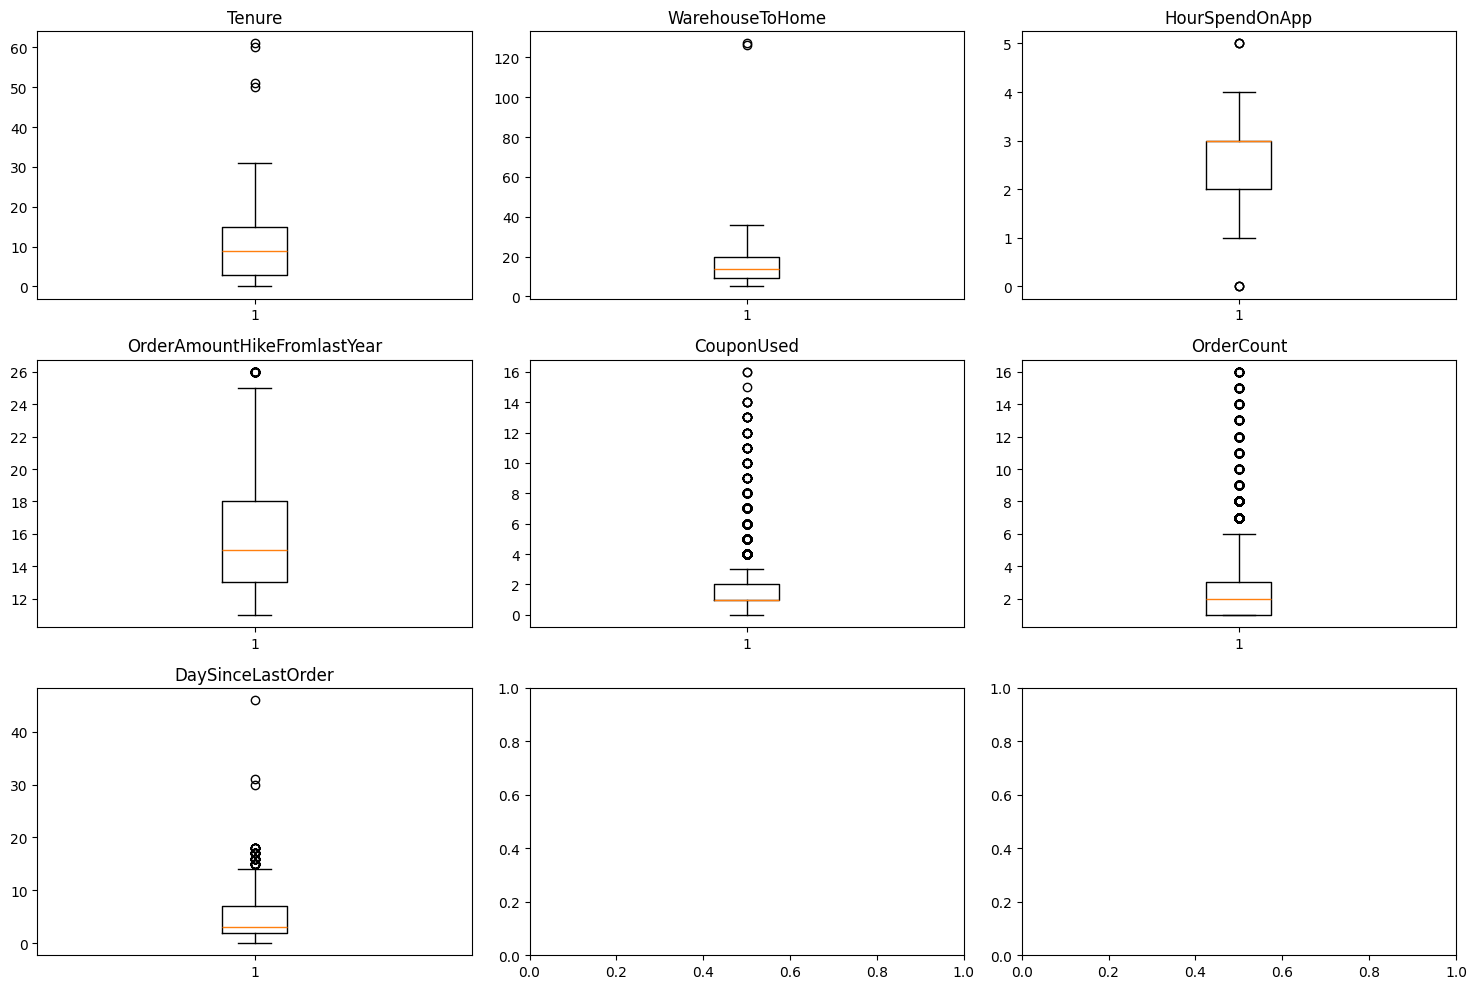

In [12]:
fig, axes = plt.subplots(3, 3, figsize = (15,10))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)
plt.tight_layout()
plt.savefig('images/outlier.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
df = df.drop(columns=['CustomerID'])
print(df.shape)

(5630, 19)


In [14]:
df['CityTier'] = df['CityTier'].astype('category')
print(df['CityTier'].dtype)

category


# 3.EDA
- Target variable = Churn (0,1)
- Distributions were compared between churned and retained customers using normalized histograms to account for class imbalance
- **Tenure**: The most notable difference between the two groups.
  Churned customers are heavily concentrated in the 0-2 month range, suggesting that newer customers are significantly more likely to churn.

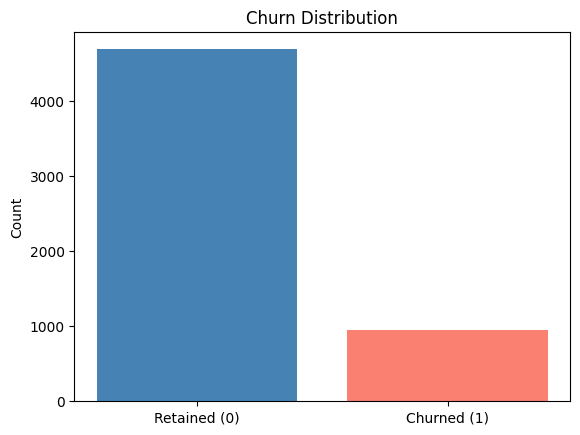

In [15]:
counts = df['Churn'].value_counts()

plt.bar(['Retained (0)', 'Churned (1)'], counts, color=['steelblue', 'salmon'])
plt.title('Churn Distribution')
plt.ylabel('Count')
plt.savefig('images/churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

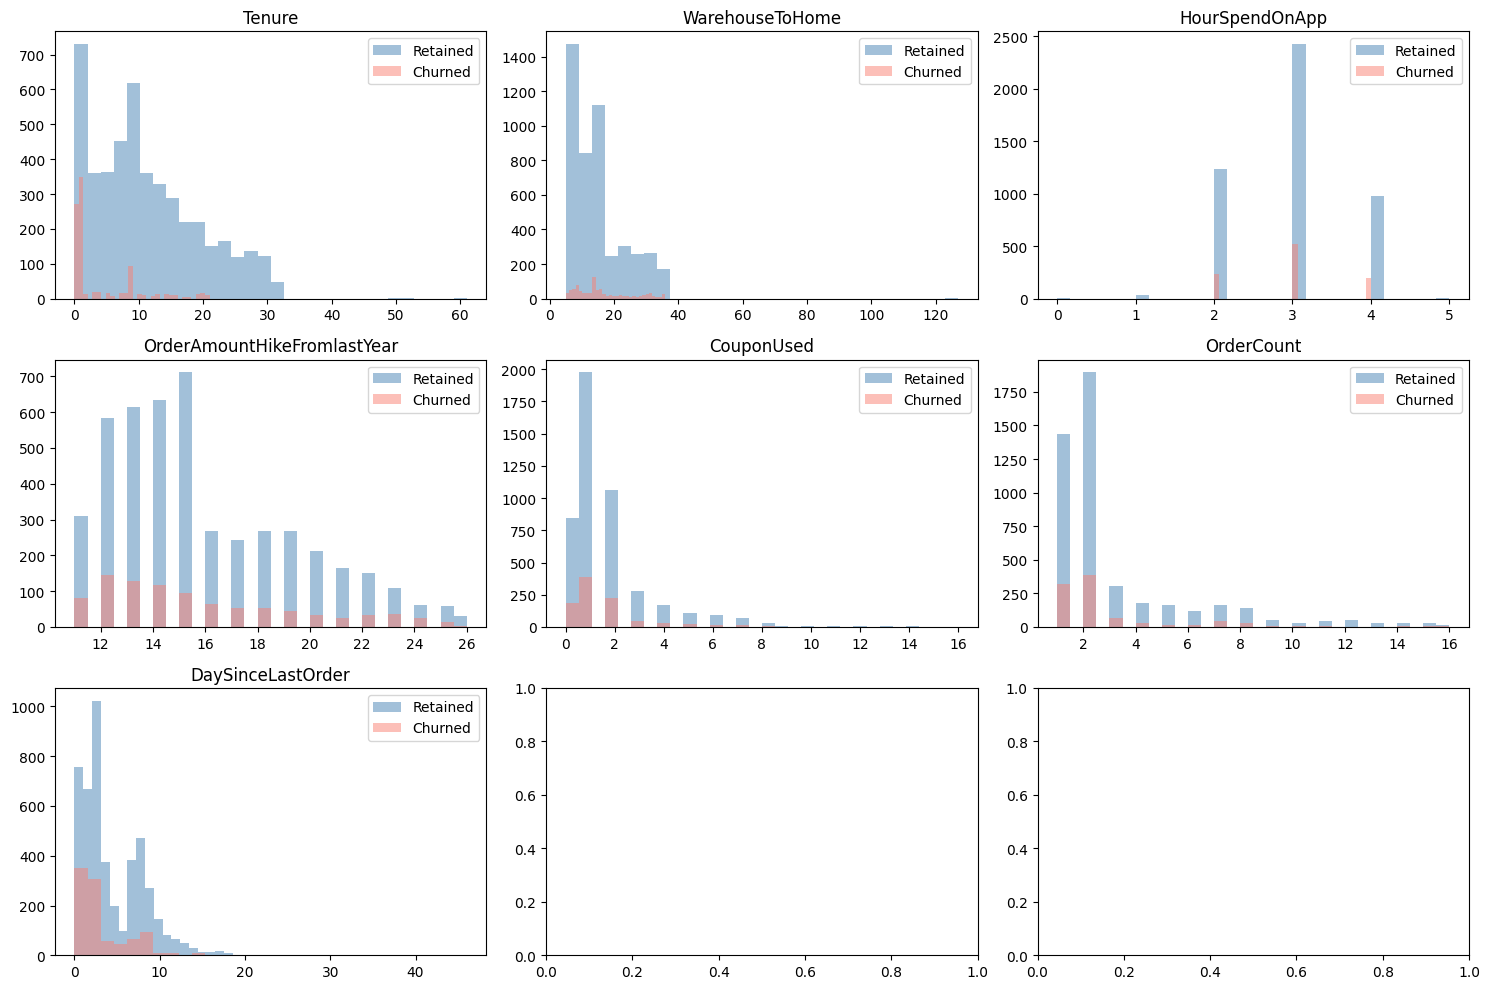

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].hist(df[df['Churn']==0][col], bins=30, alpha=0.5, label='Retained', color='steelblue')
    axes[i].hist(df[df['Churn']==1][col], bins=30, alpha=0.5, label='Churned', color='salmon')
    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()
plt.savefig('images/numerical_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

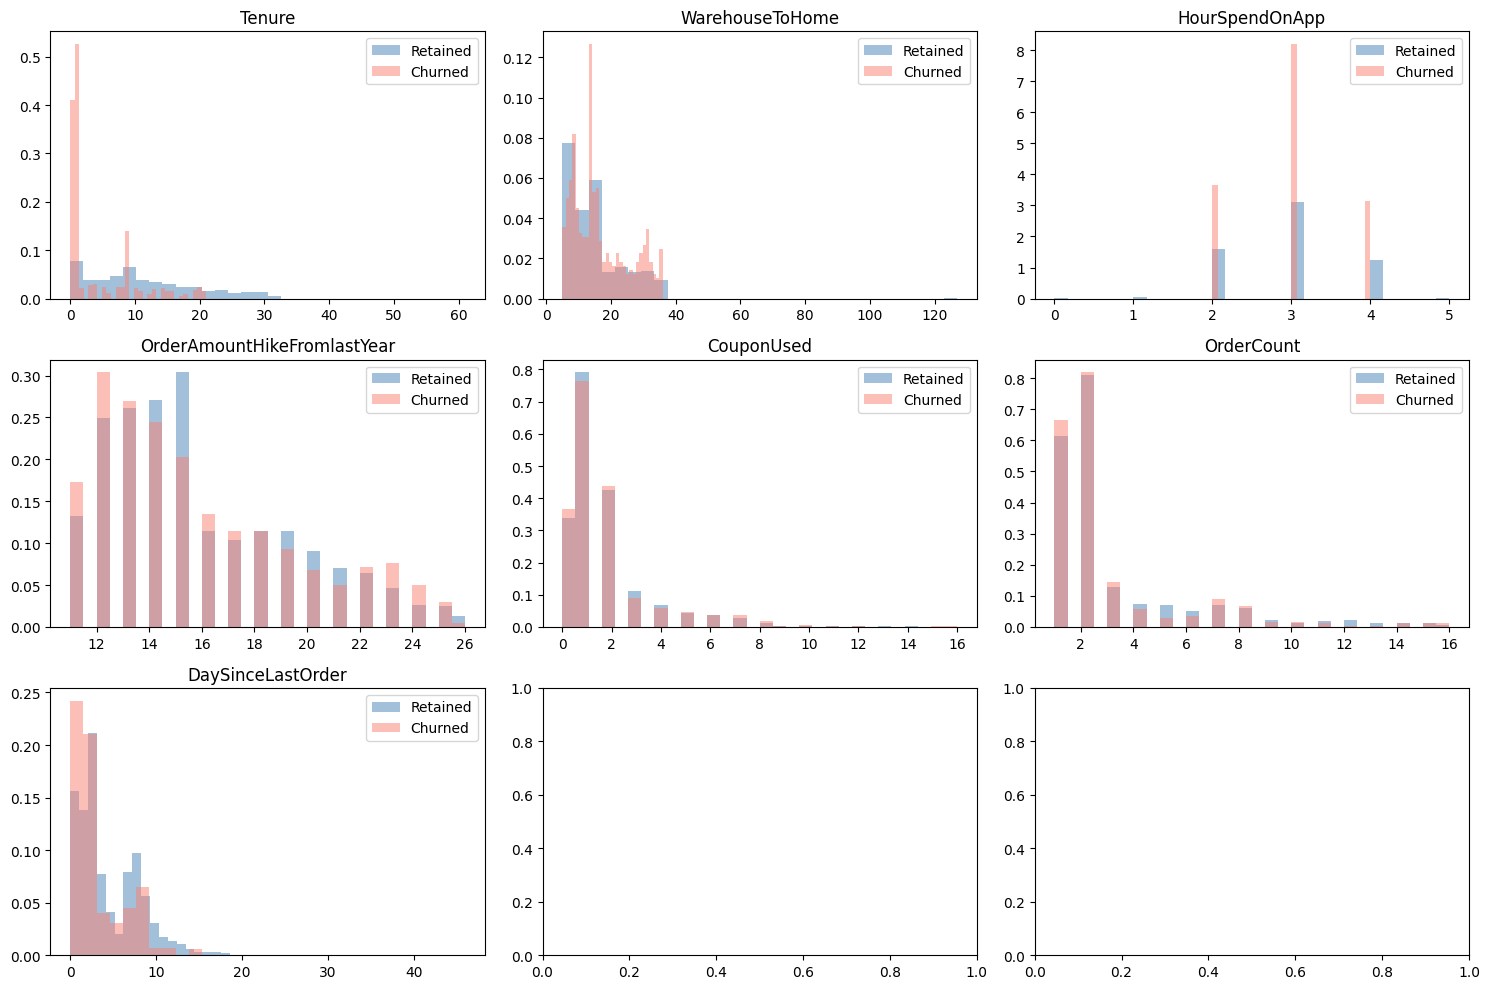

In [17]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].hist(df[df['Churn']==0][col], bins=30, alpha=0.5, 
                 label='Retained', color='steelblue', density=True)
    axes[i].hist(df[df['Churn']==1][col], bins=30, alpha=0.5, 
                 label='Churned', color='salmon', density=True)
    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()
plt.savefig('images/numerical_comparison2.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
df['CityTier'] = df['CityTier'].astype('int')

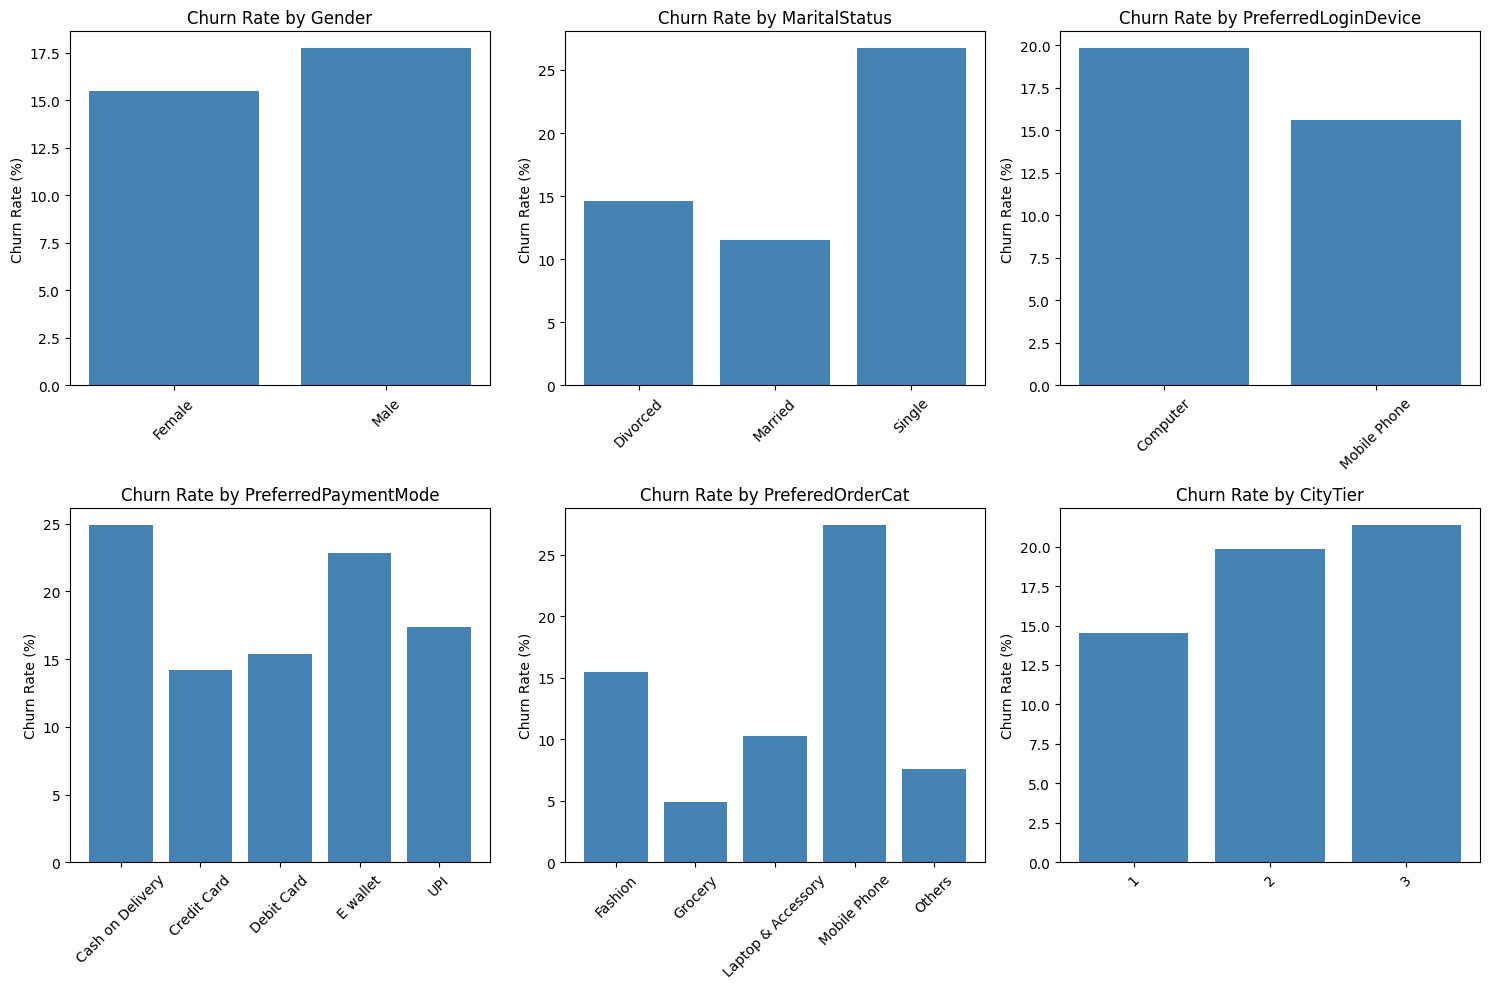

In [19]:
cat_cols = ['Gender', 'MaritalStatus', 'PreferredLoginDevice', 
            'PreferredPaymentMode', 'PreferedOrderCat', 'CityTier']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].mean() * 100
    axes[i].bar(churn_rate.index.astype(str), churn_rate.values, color='steelblue')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('images/categorical_variable.png', dpi=150, bbox_inches='tight')
plt.show()

###  Categorical Variable Analysis

Churn rate was calculated for each category to identify high-risk segments.

**Key Findings:**
- Single customers have the highest churn rate (~27%) compared to Married (~11%) and Divorced (~15%)
- Churn rate increases with city tier: Tier 1 (14.5%) → Tier 2 (20%) → Tier 3 (21%)
- Cash on Delivery and E-wallet users show higher churn rates (~25%, ~23%) vs Credit Card users (~14%)
- Mobile Phone category has the highest churn rate (~27%), Grocery the lowest (~5%)
- Computer login users churn more than Mobile Phone users (20% vs 15.5%)

Note: these are correlations, not causal relationships.

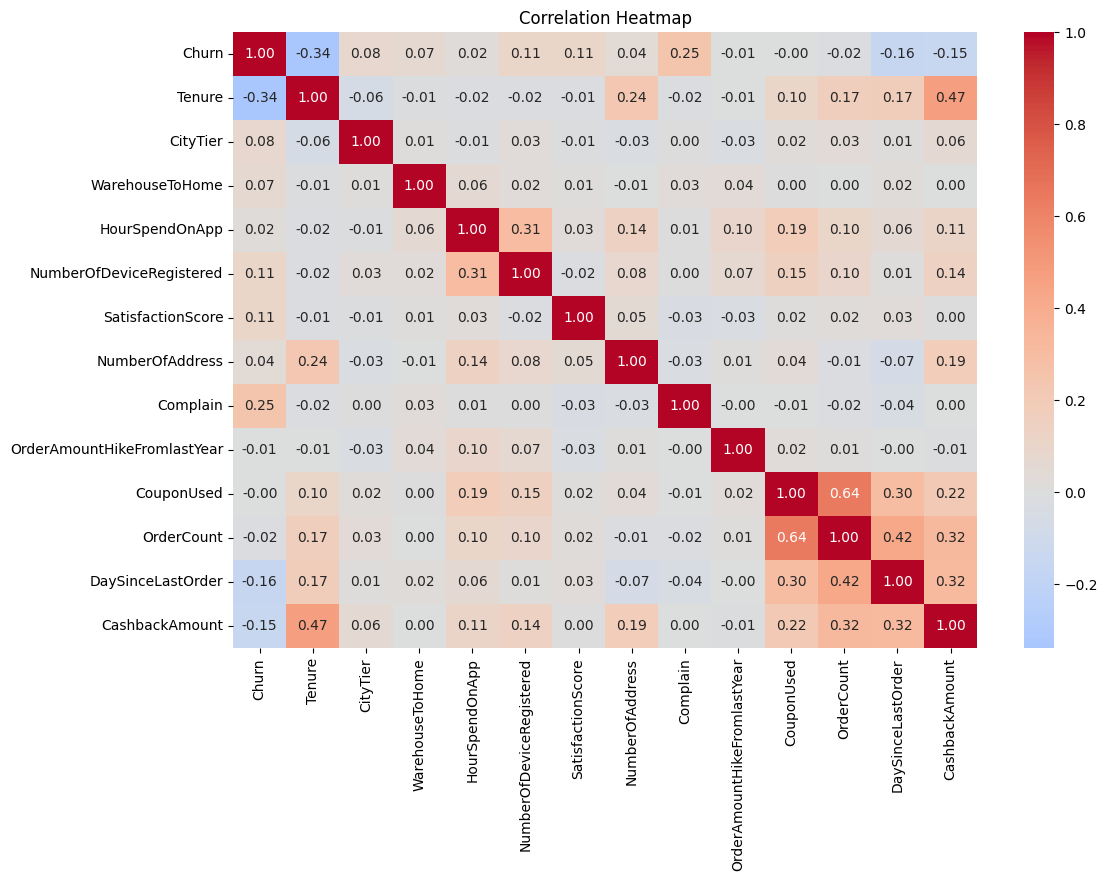

In [20]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0)
plt.title('Correlation Heatmap')
plt.savefig('images/Corrleation_Heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Hypotheses from EDA
Based on EDA, the following variables are expected to be strong predictors of churn:
- Customers with low Tenure are more likely to churn
- Customers who filed a Complain are more likely to churn
- Single customers, Mobile Phone buyers, and Cash on Delivery users show higher churn rates

These hypotheses will be validated through feature importance after modeling.


## 4.Preprocessing

In [21]:
#category - > numerical
print(df.select_dtypes(include='object').columns)

Index(['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
       'PreferedOrderCat', 'MaritalStatus'],
      dtype='str')


/var/folders/3f/k0n5zmg91134qrn136jl1q480000gn/T/ipykernel_96488/4094299581.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include='object').columns)


In [22]:
df_encoded = pd.get_dummies(df, columns=['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
       'PreferedOrderCat', 'MaritalStatus'],
                           drop_first=True)
print(df_encoded)

      Churn  Tenure  CityTier  WarehouseToHome  HourSpendOnApp  \
0         1     4.0         3              6.0             3.0   
1         1     9.0         1              8.0             3.0   
2         1     9.0         1             30.0             2.0   
3         1     0.0         3             15.0             2.0   
4         1     0.0         1             12.0             3.0   
...     ...     ...       ...              ...             ...   
5625      0    10.0         1             30.0             3.0   
5626      0    13.0         1             13.0             3.0   
5627      0     1.0         1             11.0             3.0   
5628      0    23.0         3              9.0             4.0   
5629      0     8.0         1             15.0             3.0   

      NumberOfDeviceRegistered  SatisfactionScore  NumberOfAddress  Complain  \
0                            3                  2                9         1   
1                            4                 

In [23]:
print(df_encoded.dtypes)

Churn                                    int64
Tenure                                 float64
CityTier                                 int64
WarehouseToHome                        float64
HourSpendOnApp                         float64
NumberOfDeviceRegistered                 int64
SatisfactionScore                        int64
NumberOfAddress                          int64
Complain                                 int64
OrderAmountHikeFromlastYear            float64
CouponUsed                             float64
OrderCount                             float64
DaySinceLastOrder                      float64
CashbackAmount                         float64
PreferredLoginDevice_Mobile Phone         bool
PreferredPaymentMode_Credit Card          bool
PreferredPaymentMode_Debit Card           bool
PreferredPaymentMode_E wallet             bool
PreferredPaymentMode_UPI                  bool
Gender_Male                               bool
PreferedOrderCat_Grocery                  bool
PreferedOrder

## 5. Modeling

### 5.1 Logistic Regression (Baseline)

**Results:**
- AUC: 0.8950
- Recall (Churn=1): 0.82 → captured 152 out of 185 churned customers
- Precision (Churn=1): 0.48 → only half of predicted churners were actual churners

**Business Interpretation:**
- High Recall means most churners are identified and can be targeted with retention campaigns
- Low Precision means campaigns are also sent to non-churners → wasted campaign cost
- 33 churned customers were missed → direct revenue loss

### Model Comparison

| Metric | Logistic Regression | Random Forest | XGBoost |
|--------|-------------------|---------------|---------|
| Precision (Churn=1) | 0.48 | 0.99 | 0.97 |
| Recall (Churn=1) | 0.82 | 0.84 | 0.93 |
| F1-score (Churn=1) | 0.61 | 0.91 | 0.95 |
| AUC | 0.8950 | 0.9912 | 0.9869 |

### 5.2 Model Selection
XGBoost was selected as the final model based on the following reasoning:
- Recall (0.93) is the highest among all models → captures more actual churners
- Precision difference between RF and XGBoost is negligible (0.99 vs 0.97)
- In business terms, missing a churner (low Recall) leads to direct revenue loss,
  while a false positive (low Precision) only results in wasted campaign cost

### 5.3 Baseline Reference (Logistic Regression)
- Recall (Churn=1): 0.82 → captured 152 out of 185 churned customers
- Precision (Churn=1): 0.48 → only half of predicted churners were actual churners
- 33 churned customers were missed → direct revenue loss


In [24]:
#train/test split
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(4504, 25) (1126, 25)
(4504,) (1126,)


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, mean_squared_error

lr = LogisticRegression(class_weight = 'balanced', max_iter = 1000, random_state = 42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
print(classification_report(y_test, y_pred_lr))
print(f'AUC:{roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]):.4f}')

              precision    recall  f1-score   support

           0       0.96      0.83      0.89       941
           1       0.48      0.82      0.61       185

    accuracy                           0.83      1126
   macro avg       0.72      0.82      0.75      1126
weighted avg       0.88      0.83      0.84      1126

AUC:0.8950


/Users/seonghyuek/eddiekim/ecommerce_churn/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight = 'balanced', n_estimators = 100, random_state = 42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))
print(f'AUC: {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.4f}')

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       941
           1       0.99      0.84      0.91       185

    accuracy                           0.97      1126
   macro avg       0.98      0.92      0.95      1126
weighted avg       0.97      0.97      0.97      1126

AUC: 0.9912


In [27]:
from xgboost import XGBClassifier

xgb = XGBClassifier(scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]), 
                    n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb))
print(f'AUC: {roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]):.4f}')

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       941
           1       0.97      0.93      0.95       185

    accuracy                           0.98      1126
   macro avg       0.98      0.96      0.97      1126
weighted avg       0.98      0.98      0.98      1126

AUC: 0.9869


### Cross-validation (K-fold)
To ensure the model performance is not dependent on a single train/test split,
5-fold cross-validation was applied to XGBoost

In [29]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(xgb, X, y, cv=5, scoring='roc_auc')

print(f'CV AUC Scores: {cv_scores}')
print(f'Mean AUC: {cv_scores.mean():.4f}')
print(f'Std: {cv_scores.std():.4f}')

CV AUC Scores: [1.         0.99845929 0.99881916 0.99875207 0.99994918]
Mean AUC: 0.9992
Std: 0.0006


In [30]:
print(f'Train AUC: {roc_auc_score(y_train, xgb.predict_proba(X_train)[:,1]):.4f}')
print(f'Test AUC: {roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]):.4f}')

Train AUC: 1.0000
Test AUC: 0.9869


### It seems like overfittig

In [31]:
xgb = XGBClassifier(
    scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
    n_estimators=100,
    random_state=42,
    max_depth=4,        
    learning_rate=0.1,  
    subsample=0.8,      
    colsample_bytree=0.8 
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb))
print(f'AUC: {roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]):.4f}')

              precision    recall  f1-score   support

           0       0.97      0.93      0.95       941
           1       0.70      0.87      0.78       185

    accuracy                           0.92      1126
   macro avg       0.84      0.90      0.86      1126
weighted avg       0.93      0.92      0.92      1126

AUC: 0.9619


In [32]:
print(f'Train AUC: {roc_auc_score(y_train, xgb.predict_proba(X_train)[:,1]):.4f}')
print(f'Test AUC: {roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]):.4f}')

Train AUC: 0.9846
Test AUC: 0.9619


**Note on Overfitting:**
Train AUC (1.000) is higher than Test AUC (0.987), suggesting some overfitting.
However, the gap is small and cross-validation confirms stable performance (Mean AUC: 0.9992).
Further tuning with regularization parameters is a potential future improvement.

In [33]:
from xgboost import XGBClassifier

xgb = XGBClassifier(scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]), 
                    n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb))
print(f'AUC: {roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]):.4f}')

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       941
           1       0.97      0.93      0.95       185

    accuracy                           0.98      1126
   macro avg       0.98      0.96      0.97      1126
weighted avg       0.98      0.98      0.98      1126

AUC: 0.9869


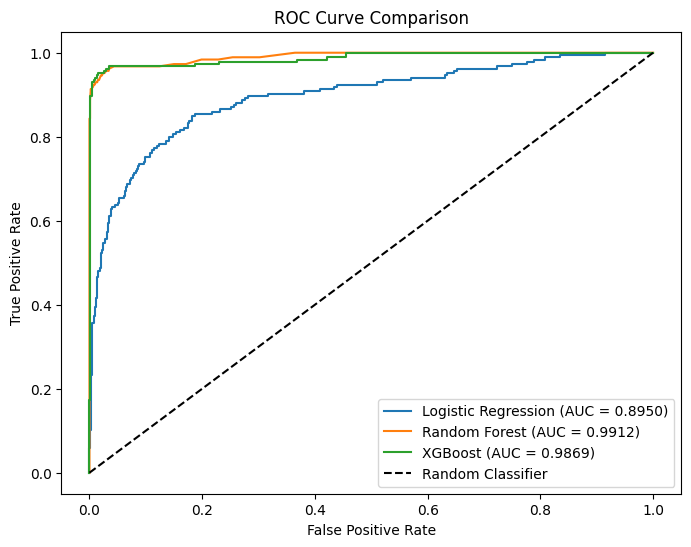

In [34]:
from sklearn.metrics import roc_curve

# Get probabilities for each model
y_proba_lr = lr.predict_proba(X_test)[:, 1]
y_proba_rf = rf.predict_proba(X_test)[:, 1]
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = 0.8950)')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = 0.9912)')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = 0.9869)')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.savefig('images/roc_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

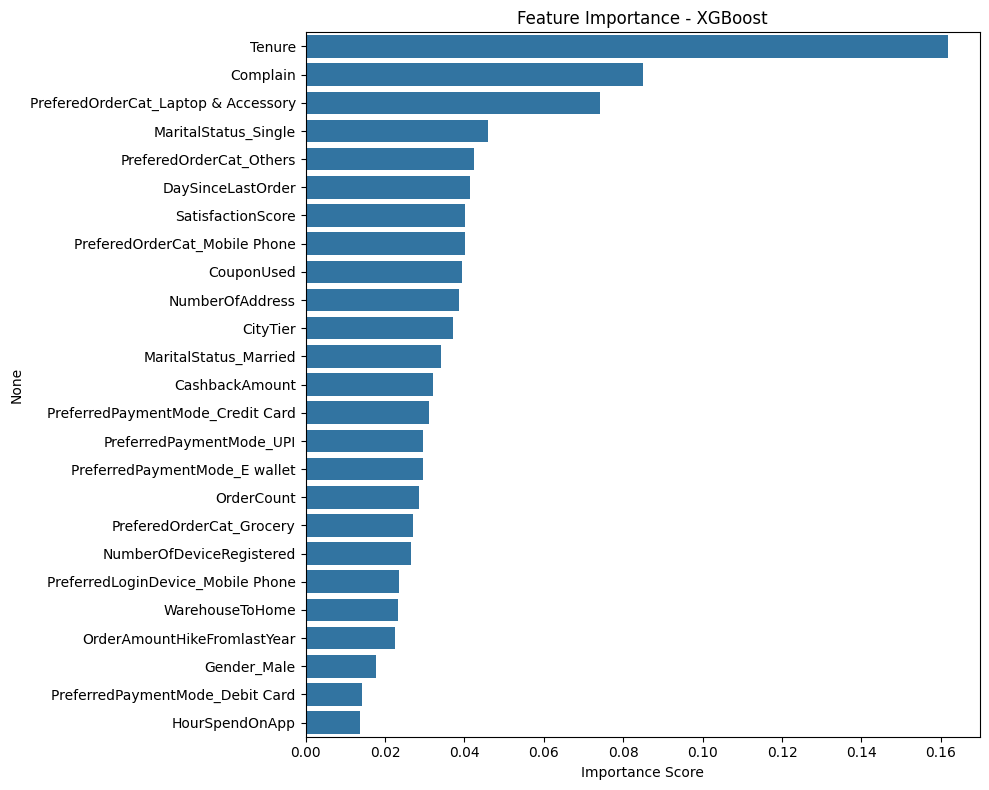

In [35]:
feature_importance = pd.Series(xgb.feature_importances_, 
                                index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x= feature_importance.values, y = feature_importance.index)
plt.title('Feature Importance - XGBoost')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('images/Feature_Importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Feature Importance

### 6.1 XGBoost Feature Importance

| Rank | Feature | Interpretation |
|------|---------|---------------|
| 1 | Tenure | Most important predictor - newer customers churn more |
| 2 | Complain | Customers who filed complaints are more likely to churn |
| 3 | PreferedOrderCat_Laptop & Accessory | Unexpected - not identified in EDA |
| 4 | MaritalStatus_Single | Single customers churn more |
| 7 | SatisfactionScore | Lower satisfaction leads to higher churn |
| 8 | PreferedOrderCat_Mobile Phone | Mobile phone buyers churn more |

### 6.2 Hypothesis Validation

| Hypothesis | Result |
|-----------|--------|
| Low Tenure → higher churn | ✅ Confirmed (Rank 1) |
| Complain → higher churn | ✅ Confirmed (Rank 2) |
| Single customers → higher churn | ✅ Confirmed (Rank 4) |
| Mobile Phone buyers → higher churn | ✅ Confirmed (Rank 8) |
| Cash on Delivery → higher churn | ❌ Not confirmed |

### 6.3 Unexpected Finding
PreferedOrderCat_Laptop & Accessory ranked 3rd, which was not identified 
as a significant factor in EDA. This suggests non-linear patterns 
that simple distribution analysis could not capture.


## 7. Cost-Benefit Analysis

### 7.1 Business Assumptions

To quantify the financial impact of churn prediction, the following costs are assumed:

| | Cost |
|---|---|
| Customer Lifetime Value (LTV) | \$200 |
| Retention Campaign Cost per customer | \$10 |

**Cost Framework:**

| | Actual Churn (1) | Actual Retained (0) |
|---|---|---|
| Predicted Churn (1) | TP: \$10 campaign cost, churn prevented ✅ | FP: \$10 wasted campaign cost |
| Predicted Retained (0) | FN: \$200 revenue loss ❌ | TN: \$0 |

### 7.2 Goal
Find the optimal threshold that minimizes total business cost.

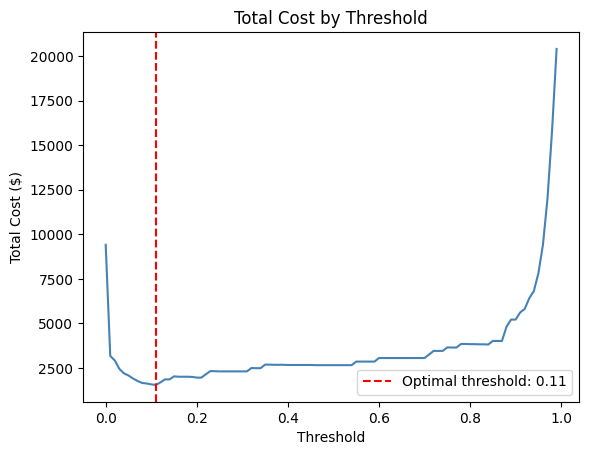

Optimal threshold: 0.11
Minimum total cost: $1540


In [36]:
# Get predicted probabilities
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

# Cost assumptions
cost_fn = 200  # revenue loss per missed churner
cost_fp = 10   # campaign cost per non-churner

# Calculate total cost for each threshold
thresholds = np.arange(0, 1, 0.01)
total_costs = []

for threshold in thresholds:
    y_pred_thresh = (y_proba_xgb >= threshold).astype(int)
    
    fp = ((y_pred_thresh == 1) & (y_test == 0)).sum()
    fn = ((y_pred_thresh == 0) & (y_test == 1)).sum()
    
    total_cost = (fp * cost_fp) + (fn * cost_fn)
    total_costs.append(total_cost)

# Plot
plt.plot(thresholds, total_costs, color='steelblue')
plt.xlabel('Threshold')
plt.ylabel('Total Cost ($)')
plt.title('Total Cost by Threshold')
plt.axvline(thresholds[np.argmin(total_costs)], color='red', linestyle='--', 
            label=f'Optimal threshold: {thresholds[np.argmin(total_costs)]:.2f}')
plt.legend()
plt.savefig('images/Cost by Threshold.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Optimal threshold: {thresholds[np.argmin(total_costs)]:.2f}')
print(f'Minimum total cost: ${min(total_costs)}')

In [37]:
# No model - all churners are missed
baseline_cost = len(y_test[y_test==1]) * cost_fn
print(f'Baseline cost (no model): ${baseline_cost}')
print(f'Cost with model: $1540')
print(f'Cost saving: ${baseline_cost - 1540} ({(baseline_cost - 1540)/baseline_cost*100:.1f}%)')

Baseline cost (no model): $37000
Cost with model: $1540
Cost saving: $35460 (95.8%)


### 8.2 Results

| | Value |
|---|---|
| Optimal Threshold | 0.11 |
| Minimum Total Cost | \$1,540 |
| Baseline Cost (no model) | \$37,000 |
| Cost Saving | 35,460 (95.8%) |
### 8.3 Conclusion
By applying XGBoost with an optimal threshold of 0.11, 
the business can reduce churn-related costs by 95.8% 
compared to taking no action.

At this threshold, customers with a predicted churn probability 
above 11% are targeted with a 10 USD retention campaign, 
minimizing the total cost of false negatives (200 USD revenue loss) 
and false positives (10 USD wasted campaign cost).